## Necessary Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
import matplotlib.pyplot as plt

latent_dim = 128  # Latent vector size


## Load and preprocess CIFAR-10

In [ ]:

(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0  # Normalize to [0,1]
print(x_train.shape)  

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3)


## Encoder & Decoder build

In [3]:
latent_dim = 128

# Encoder section
def build_encoder(latent_dim=128):
    encoder = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same', strides=2),
        layers.Conv2D(64, 3, activation='relu', padding='same', strides=2),
        layers.Conv2D(128, 3, activation='relu', padding='same', strides=2),
        layers.Flatten(),
        layers.Dense(latent_dim)
    ])
    return encoder

#  Decoder Section
def build_decoder(latent_dim=128):
    decoder = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(4*4*128),
        layers.Reshape((4, 4, 128)),
        layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu'),
        layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
        layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
        layers.Conv2DTranspose(3, 3, padding='same', activation='sigmoid')
    ])
    return decoder


## Build and Train Normal Autoencoder

In [4]:
# Instantiate encoder and decoder
encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)

# Create functional model
input_img = Input(shape=(32, 32, 3))
encoded = encoder(input_img)
decoded = decoder(encoded)

autoencoder = models.Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Training the model
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, shuffle=True)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128)            │       355,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │       504,899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 860,419 (3.28 MB)

 Trainable params: 860,419 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.0332
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0102
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0080
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0067
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0060
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0057
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0055
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0053
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0051
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0050


## Build and Train Denoising Autoencoder

In [5]:
# Add Gaussian noise
noise_factor = 0.2
noisy_x_train = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
noisy_x_train = np.clip(noisy_x_train, 0.0, 1.0)

# New encoder and decoder for denoising AE
encoder_denoise = build_encoder(latent_dim)
decoder_denoise = build_decoder(latent_dim)

# Functional model for denoising
input_img_denoise = Input(shape=(32, 32, 3))
encoded_denoise = encoder_denoise(input_img_denoise)
decoded_denoise = decoder_denoise(encoded_denoise)

autoencoder_denoise = models.Model(inputs=input_img_denoise, outputs=decoded_denoise)
autoencoder_denoise.compile(optimizer='adam', loss='mse')
autoencoder_denoise.summary()

# Train
autoencoder_denoise.fit(noisy_x_train, x_train, epochs=10, batch_size=128, shuffle=True)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 128)            │       355,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │       504,899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 860,419 (3.28 MB)

 Trainable params: 860,419 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0342
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0113
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0095
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0085
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0076
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0071
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0069
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0067
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0066
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0064


In [6]:
mean = 5.0
variance = 1.0
std_dev = np.sqrt(variance)

# Generate 5 latent vectors
noise_vectors = np.random.normal(loc=mean, scale=std_dev, size=(5, latent_dim))

# Generate images using the trained decoders
generated_normal = decoder.predict(noise_vectors)
generated_denoise = decoder_denoise.predict(noise_vectors)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


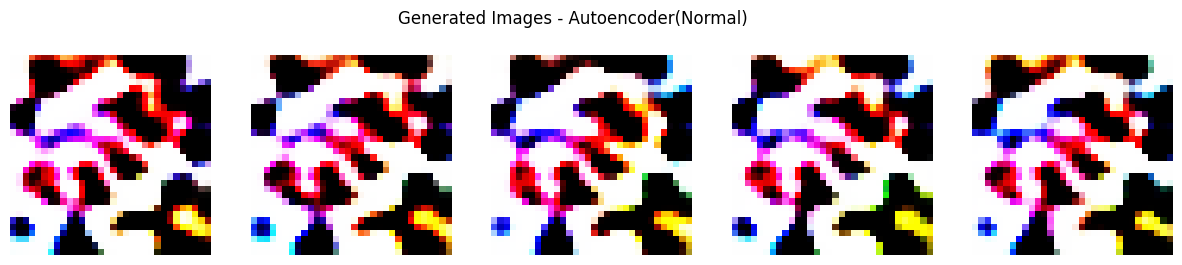

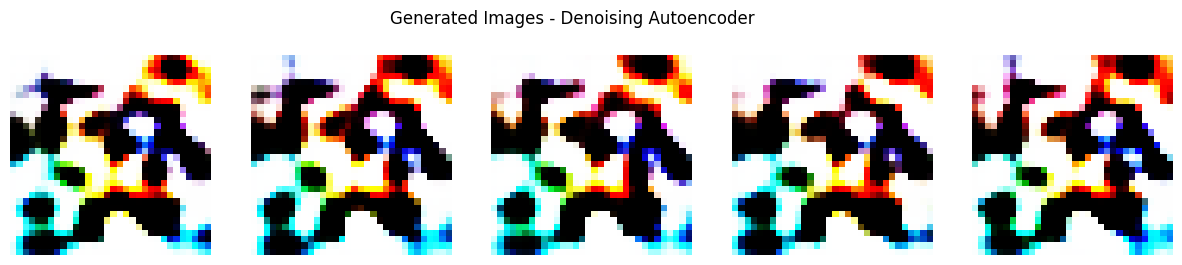

In [8]:
def plot_images(images, title):
    plt.figure(figsize=(15, 3))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_images(generated_normal, "Generated Images - Autoencoder(Normal)")
plot_images(generated_denoise, "Generated Images - Denoising Autoencoder")
